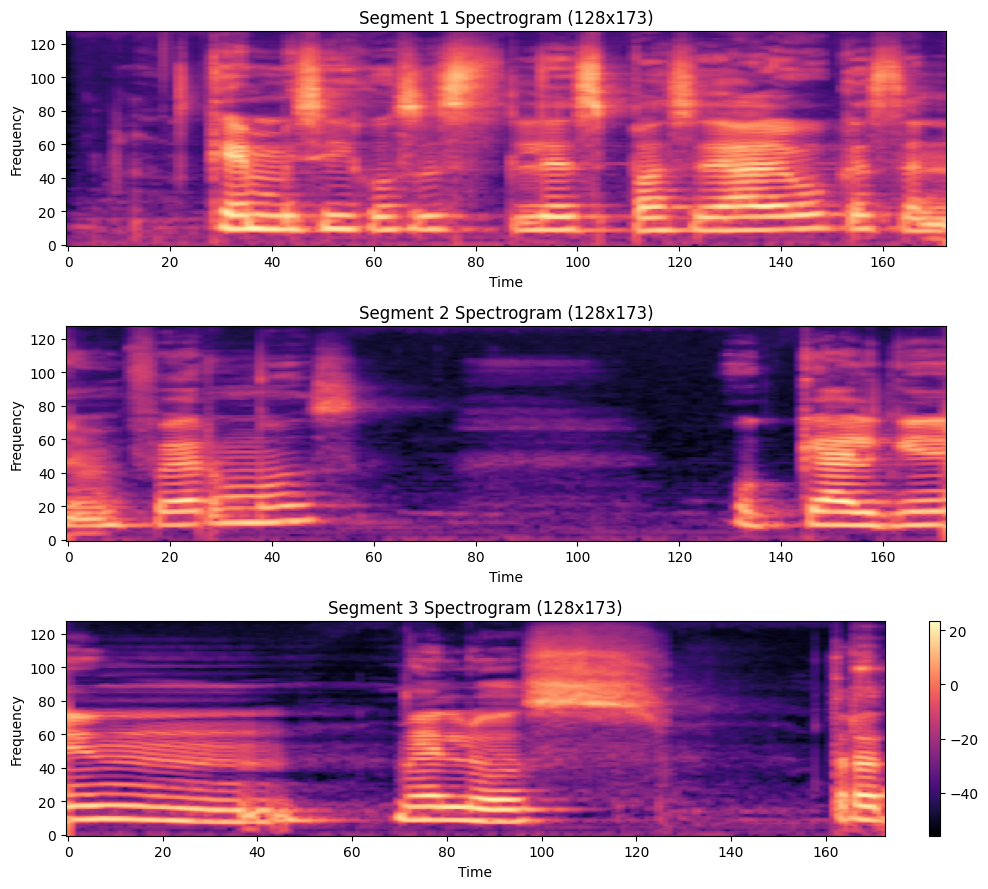

📌 Iniciando entrenamiento con 10-Fold Cross-Validation...
📌 Cargando y procesando audios en tiempo de ejecución...
⚠️ OMITIENDO: 116_13.wav - Duración insuficiente (1.94 s)
📌 Total de muestras cargadas: 15990
📌 Espectrograma generado - Shape: torch.Size([1, 128, 128])
📌 Espectrograma generado - Shape: torch.Size([1, 128, 128])
📌 Espectrograma generado - Shape: torch.Size([1, 128, 128])
📌 Espectrograma generado - Shape: torch.Size([1, 128, 128])
📌 Espectrograma generado - Shape: torch.Size([1, 128, 128])
📌 Espectrograma generado - Shape: torch.Size([1, 128, 128])
📌 Espectrograma generado - Shape: torch.Size([1, 128, 128])
📌 Espectrograma generado - Shape: torch.Size([1, 128, 128])
📌 Espectrograma generado - Shape: torch.Size([1, 128, 128])
📌 Espectrograma generado - Shape: torch.Size([1, 128, 128])
📌 Espectrograma generado - Shape: torch.Size([1, 128, 128])
📌 Espectrograma generado - Shape: torch.Size([1, 128, 128])
📌 Espectrograma generado - Shape: torch.Size([1, 128, 128])
📌 Espectrog

In [1]:
# %% [markdown]
# # ERpncoding

# %%
from sklearn.model_selection import StratifiedKFold
import torch
import torch.nn as nn
import torch.nn.functional as F
import csv
import numpy as np
from pyDOE2 import lhs
import sys
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix
#sys.stdout = open('/dev/null', 'w')  # Redirigir la salida a /dev/null
import os
import pandas as pd
import torchaudio
import torch.optim as optim
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tqdm import tqdm
from torch.utils.data import TensorDataset, DataLoader,Dataset
import json
import torch.multiprocessing as mp
import torchaudio.transforms as T
from torch.cuda.amp import autocast, GradScaler
import torch.utils.checkpoint as checkpoint


    
    # 🔹 Optimización de cuDNN
torch.backends.cudnn.benchmark = True
torch.backends.cudnn.deterministic = False
#torch.set_num_threads(1)  # Prueba con 4, 2 o 1
#torch.set_num_interop_threads(1)

#import torch.multiprocessing as mp
#mp.set_start_method('spawn', force=True)

# %%
# Opciones de decodificación para otros parámetros
layer_type_options = {
    0: 'Conv2D', 
    1: 'BatchNorm', 
    2: 'MaxPooling', 
    3: 'Dropout', 
    4: 'Dense', 
    5: 'Flatten',
    6: 'SelfAttention',  # Reemplazo de DepthwiseConv2D por Self-Attention
    7: 'DontCare',  
    8: 'Repetition'
}

stride_options = {0: 1, 1: 2}
dropout_options = {0: 0.2, 1: 0.3, 2: 0.4, 3: 0.5}
activation_options = {0: 'relu', 1: 'leaky_relu', 2: 'sigmoid', 3: 'tanh'}

# Función para codificar los parámetros de la capa
def encode_layer_params(layer_type_idx, param1=0, param2=0, param3=0):
    """
    Codifica una capa en una lista en función del tipo de capa y sus parámetros.
    
    layer_type_idx : int : índice del tipo de capa según layer_type_options.
    param1         : int/float : filtros, neuronas, capas de repetición, etc.
    param2         : int : stride, número de repeticiones, etc.
    param3         : int : índice de activación o tasa de dropout.
    """
    return [layer_type_idx, param1, param2, param3]

def decode_layer_params(encoded_params):
    """
    Decodifica una capa desde su representación codificada en parámetros interpretables.
    
    encoded_params : list : [tipo de capa, param1, param2, param3].
    """
    layer_type_idx = encoded_params[0]
    layer_type = layer_type_options.get(layer_type_idx, 'DontCare')
    
    # Decodificar en función del tipo de capa
    if layer_type == 'Conv2D':
        filters = max(4, min(encoded_params[1], 32))  # Limitar filtros entre 4 y 32
        strides = stride_options.get(encoded_params[2], 1)
        activation = activation_options.get(encoded_params[3], 'relu')
        return {
            'type': 'Conv2D',
            'filters': filters,
            'strides': strides,
            'activation': activation
        }
    elif layer_type == 'BatchNorm':
        return {'type': 'BatchNorm'}
    elif layer_type == 'MaxPooling':
        strides = stride_options.get(encoded_params[1], 1)
        return {'type': 'MaxPooling', 'strides': strides}
    elif layer_type == 'Dropout':
        rate = dropout_options.get(encoded_params[1], 0.2)
        return {'type': 'Dropout', 'rate': rate}
    elif layer_type == 'Dense':
        units = max(1, min(encoded_params[1], 512))  # Limitar unidades entre 1 y 512
        activation = activation_options.get(encoded_params[2], 'relu')
        return {'type': 'Dense', 'units': units, 'activation': activation}
    elif layer_type == 'Flatten':
        return {'type': 'Flatten'}
    elif layer_type == 'Repetition':
        return {
            'type': 'Repetition',
            'repetition_layers': int(encoded_params[1]),
            'repetition_count': int(encoded_params[2])
        }
    elif layer_type == 'SelfAttention':
        filters = max(4, min(encoded_params[1], 64))  # Atención con 4-64 filtros
        attention_heads = max(1, min(encoded_params[2], 8))  # Máximo 8 cabezas de atención
        activation = activation_options.get(encoded_params[3], 'relu')  # Activación opcional
        return {
            'type': 'SelfAttention',
            'filters': filters,
            'attention_heads': attention_heads,
            'activation': activation
        }
    elif layer_type == 'DontCare':
        return {'type': "DontCare"}

    return None




# %% [markdown]
# ## Complete archs
# 

# %%

import torch
import torch.nn as nn
import torch.nn.functional as F


import torch
import torch.nn as nn
import torch.nn.functional as F

import torch
import torch.nn as nn
import torch.nn.functional as F

class SelfAttention(nn.Module):
    def __init__(self, filters, window_size=8, attention_heads=4, activation=nn.ReLU(), verbose=False):
        super(SelfAttention, self).__init__()
        if filters % attention_heads != 0:
            if verbose:
                print(f"Warning: {filters} no es divisible por {attention_heads}. Ajustando filters.")
            filters = filters - (filters % attention_heads)
            filters = max(filters, attention_heads)

        self.filters = filters
        self.attention_heads = attention_heads
        self.window_size = window_size
        self.verbose = verbose
        self.d_head = self.filters // self.attention_heads  # Canales por cabeza
        
        # Inicializar convoluciones como None para configurarlas en forward()
        self.query_conv = None
        self.key_conv = None
        self.value_conv = None
        self.projection_conv = None

    def forward(self, x):
        B, C, H, W = x.shape
        ws = min(self.window_size, H, W)  # Asegurar que `window_size` no sea mayor que H o W
        
        # Padding si H o W no son múltiplos de window_size
        pad_h = (ws - H % ws) % ws
        pad_w = (ws - W % ws) % ws
        if pad_h > 0 or pad_w > 0:
            x = F.pad(x, (0, pad_w, 0, pad_h))
            H, W = x.shape[2], x.shape[3]
        
        num_windows_h = H // ws
        num_windows_w = W // ws
        x_windows = x.view(B, C, num_windows_h, ws, num_windows_w, ws)
        x_windows = x_windows.permute(0, 2, 4, 1, 3, 5).contiguous()
        windows = x_windows.view(-1, C, ws, ws)

        # Ajustar convoluciones dinámicamente
        if self.query_conv is None or self.query_conv.in_channels != C:
            self.query_conv = nn.Conv2d(in_channels=C, out_channels=self.filters, kernel_size=1).to(x.device)
            self.key_conv = nn.Conv2d(in_channels=C, out_channels=self.filters, kernel_size=1).to(x.device)
            self.value_conv = nn.Conv2d(in_channels=C, out_channels=self.filters, kernel_size=1).to(x.device)

        Q = self.query_conv(windows)
        K = self.key_conv(windows)
        V = self.value_conv(windows)

        B_w, C_w, H_w, W_w = Q.shape
        N = H_w * W_w
        Q = Q.view(B_w, self.attention_heads, self.d_head, N).permute(0, 1, 3, 2)
        K = K.view(B_w, self.attention_heads, self.d_head, N).permute(0, 1, 3, 2)
        V = V.view(B_w, self.attention_heads, self.d_head, N).permute(0, 1, 3, 2)

        attn = torch.matmul(Q, K.transpose(-2, -1)) / (self.d_head ** 0.5)
        attn = F.softmax(attn, dim=-1)
        out_window = torch.matmul(attn, V)

        out_window = out_window.permute(0, 1, 3, 2).contiguous()

        # Validación antes de `view()`
        expected_elements_out = B * C * num_windows_h * ws * num_windows_w * ws
        actual_elements_out = out_window.numel()

        if expected_elements_out != actual_elements_out:
            print(f"⚠️ ERROR: Tamaño incompatible en `view()`")
            print(f"Esperado: {expected_elements_out}, Real: {actual_elements_out}")
            print(f"Forma de `out_window` antes de `view()`: {out_window.shape}")
            
            # Ajuste seguro
            out = out_window.reshape(B, C, -1, num_windows_w * ws)
        else:
            out = out_window.view(B, C, num_windows_h * ws, num_windows_w * ws)

        if pad_h > 0 or pad_w > 0:
            out = out[:, :, :H - pad_h, :W - pad_w]
        return out






# Capa de identidad (DontCareLayer)
class DontCareLayer(nn.Module):
    def __init__(self):
        super(DontCareLayer, self).__init__()

    def forward(self, x):
        return x

# %%
def encode_model_architecture(model_dict, max_alleles=48):
    """
    Codifica la arquitectura del modelo en una lista de valores con un máximo de `max_alleles`.
    Cada capa se codifica en función de sus parámetros.
    """
    encoded_layers = []
    total_alleles = 0

    for layer in model_dict['layers']:
        if layer['type'] == 'Repetition':  # Codificar capa de repetición
            encoded_layer = encode_layer_params(
                layer_type_idx=8,  # índice para 'Repetition'
                param1=layer.get('repetition_layers', 0),
                param2=layer.get('repetition_count', 1)
            )
        else:
            layer_type_idx = next(
                key for key, value in layer_type_options.items() if value == layer['type']
            )
            
            # Codificar parámetros específicos de cada tipo de capa
            if layer['type'] == 'Conv2D':  
                param1 = max(4, min(layer.get('filters', 8), 32))  # Limitar filtros dentro del rango [4, 32]
                param2 = next((key for key, value in stride_options.items() if value == layer.get('strides', 1.0)), 0)
                param3 = next((key for key, value in activation_options.items() if value == layer.get('activation', 'relu')), 0)
                encoded_layer = [layer_type_idx, param1, param2, param3]

            elif layer['type'] == 'SelfAttention':  # Reemplazo de DepthwiseConv2D por SelfAttention
                param1 = max(4, min(layer.get('filters', 8), 64))  # Limitar filtros dentro del rango [4, 64]
                param2 = max(1, min(layer.get('attention_heads', 1), 8))  # Número de cabezas de atención [1, 8]
                param3 = next((key for key, value in activation_options.items() if value == layer.get('activation', 'relu')), 0)
                encoded_layer = [layer_type_idx, param1, param2, param3]

            elif layer['type'] == 'Dense':
                param1 = max(1, min(layer.get('units', 1), 512))  # Limitar neuronas dentro del rango [1, 512]
                param2 = next((key for key, value in activation_options.items() if value == layer.get('activation', 'relu')), 0)
                encoded_layer = [layer_type_idx, param1, param2, 0]

            elif layer['type'] == 'MaxPooling':
                param1 = next((key for key, value in stride_options.items() if value == layer.get('strides', 1.0)), 0)
                encoded_layer = [layer_type_idx, param1, 0, 0]

            elif layer['type'] == 'Dropout':
                param1 = next((key for key, value in dropout_options.items() if value == layer.get('rate', 0.2)), 0)
                encoded_layer = [layer_type_idx, param1, 0, 0]

            elif layer['type'] == 'BatchNorm':
                encoded_layer = [layer_type_idx, 0, 0, 0]

            elif layer['type'] == 'Flatten':
                encoded_layer = [layer_type_idx, 0, 0, 0]

            elif layer['type'] == 'DontCare':
                encoded_layer = [layer_type_idx, 0, 0, 0]

        # Añadir la codificación de la capa a la lista de alelos
        encoded_layers.extend(encoded_layer)
        total_alleles += len(encoded_layer)

    # Rellenar con 'DontCare' si el total de alelos es menor que `max_alleles`
    while total_alleles < max_alleles:
        dont_care_encoding = encode_layer_params(7)  # índice de 'DontCare'
        encoded_layers.extend(dont_care_encoding)
        total_alleles += len(dont_care_encoding)

    # Recortar si excede `max_alleles`
    final_encoding = encoded_layers[:max_alleles]
    print(f"Final Encoded Model: {final_encoding}")
    
    return final_encoding


# %%


def fixArch(encoded_model, verbose=False):
    """
    Corrige la arquitectura codificada del modelo, asegurando que:
    - Se evite la presencia de capas incompatibles después de una capa Dense.
    - En caso de una capa de Repetition, se ajuste el alcance de repetición si no hay suficientes capas anteriores.
    - Limita la arquitectura a una sola capa de SelfAttention.
    
    Parameters:
        encoded_model (list): Lista codificada de la arquitectura del modelo.
        verbose (bool): Si es True, muestra las correcciones realizadas.

    Returns:
        list: Lista con la arquitectura corregida, truncada a un máximo de 48 alelos.
    """
    
    fixed_layers = []         # Lista que almacenará la arquitectura corregida
    input_is_flattened = False # Indicador para saber si ya hay una capa Flatten en el modelo
    dense_started = False      # Indicador para saber si ya se ha encontrado una capa Dense
    index = 0                  # Índice para recorrer el modelo codificado
    found_self_attention = False  # Flag para rastrear la primera aparición de SelfAttention

    while index < len(encoded_model) and len(fixed_layers) < 48:
        layer_type = int(encoded_model[index])  # Obtener el tipo de capa actual

        # Si ya se ha procesado una capa Dense, sólo se permiten Dense, BatchNorm o DontCare
        if dense_started and layer_type not in [4, 1, 7]:
            if verbose:
                print(f"Se encontró una capa de tipo {layer_type} después de una Dense, reemplazando con DontCare")
            fixed_layers.extend([7, 0, 0, 0])
            index += 4
            continue

        # Procesar la capa de Repetition
        if layer_type == 8:
            repetition_layers = int(encoded_model[index + 1])
            repetition_count = min(max(int(encoded_model[index + 2]), 0), 32)
            actual_layers_to_repeat = min(repetition_layers, len(fixed_layers) // 4)
            if actual_layers_to_repeat != repetition_layers:
                if verbose:
                    print(f"Ajustando alcance de repetición de {repetition_layers} a {actual_layers_to_repeat} debido a falta de capas.")
                repetition_layers = actual_layers_to_repeat
            fixed_layers.extend([layer_type, repetition_layers, repetition_count, 0])
            index += 4
            continue

        # Procesar cada tipo de capa normal
        if layer_type == 0:  # Conv2D
            if input_is_flattened:
                fixed_layers.extend([7, 0, 0, 0])  # DontCare
            else:
                filters = min(max(int(encoded_model[index + 1]), 4), 32)
                stride_idx = min(max(int(encoded_model[index + 2]), 0), 1)
                activation_idx = min(max(int(encoded_model[index + 3]), 0), 3)
                fixed_layers.extend([layer_type, filters, stride_idx, activation_idx])

        elif layer_type == 6:  # SelfAttention
            if input_is_flattened or found_self_attention:
                fixed_layers.extend([7, 0, 0, 0])
                if verbose and found_self_attention:
                    print("Capa SelfAttention adicional reemplazada con DontCare.")
            else:
                filters = min(max(int(encoded_model[index + 1]), 4), 64)
                attention_heads = min(max(int(encoded_model[index + 2]), 1), 4)
                activation_idx = min(max(int(encoded_model[index + 3]), 0), 3)
                # Ajustar filters para que sea divisible por attention_heads:
                if filters % attention_heads != 0:
                    nuevo_valor = filters - (filters % attention_heads)
                    if verbose:
                        print(f"Warning: SelfAttention filters {filters} no es divisible por attention_heads {attention_heads}. Ajustando filters a {nuevo_valor}")
                    filters = nuevo_valor if nuevo_valor >= 4 else 4  # Asegurarse de que no sea menor que 4
                fixed_layers.extend([layer_type, filters, attention_heads, activation_idx])
                found_self_attention = True

        elif layer_type == 2:  # MaxPooling
            if input_is_flattened:
                fixed_layers.extend([7, 0, 0, 0])
            else:
                stride_idx = min(max(int(encoded_model[index + 1]), 0), 1)
                fixed_layers.extend([layer_type, stride_idx, 0, 0])

        elif layer_type == 3:  # Dropout
            rate_idx = min(max(int(encoded_model[index + 1]), 0), 3)
            fixed_layers.extend([layer_type, rate_idx, 0, 0])

        elif layer_type == 4:  # Dense
            neurons = min(max(int(encoded_model[index + 1]), 1), 512)
            activation_idx = min(max(int(encoded_model[index + 2]), 0), 3)
            fixed_layers.extend([layer_type, neurons, activation_idx, 0])
            dense_started = True  # Marcar que ya se encontró una capa Dense

        elif layer_type == 1:  # BatchNorm
            if len(fixed_layers) > 0:
                prev_layer = fixed_layers[-4:]
                prev_layer_type = prev_layer[0]
                if prev_layer_type in [0, 6]:
                    num_features = prev_layer[1]
                else:
                    num_features = 4
            else:
                num_features = 4
            if verbose:
                print(f"📌 Configurando BatchNorm con {num_features} canales")
            fixed_layers.extend([layer_type, num_features, 0, 0])

        elif layer_type == 5:  # Flatten
            if input_is_flattened or dense_started:
                fixed_layers.extend([7, 0, 0, 0])
            else:
                if index + 4 < len(encoded_model):
                    next_layer_type = int(encoded_model[index + 4])
                    if next_layer_type not in [4, 7]:  # Flatten debería ir seguido de Dense o DontCare
                        if verbose:
                            print(f"⚠️ WARNING: Flatten seguido de {next_layer_type}, reemplazando con DontCare")
                        fixed_layers.extend([7, 0, 0, 0])
                    else:
                        fixed_layers.extend([layer_type, 0, 0, 0])
                        input_is_flattened = True
                else:
                    fixed_layers.extend([layer_type, 0, 0, 0])
                    input_is_flattened = True

        elif layer_type == 7:  # DontCare
            fixed_layers.extend([layer_type, 0, 0, 0])

        else:  # Cualquier otro tipo
            fixed_layers.extend([7, 0, 0, 0])

        index += 4

    return fixed_layers[:48]



# %%
def decode_model_architecture(encoded_model):
    """
    Decodifica la arquitectura del modelo a partir de la lista codificada de valores (índices),
    aplicando las reglas de repetición y asegurando la inclusión de una capa convolucional inicial.
    """
    model_dict = {'layers': []}  # Lista de capas decodificadas
    index = 0
    found_self_attention = False  # Flag para asegurar una sola SelfAttention

    while index < len(encoded_model):
        layer_type = int(encoded_model[index])
        param1 = encoded_model[index + 1]
        param2 = encoded_model[index + 2]
        param3 = encoded_model[index + 3]

        if layer_type == 8:  # Capa de Repetition
            repetition_layers = int(param1)
            repetition_count = int(param2)

            # Selecciona solo capas válidas para la repetición (sin incluir SelfAttention)
            layers_to_repeat = select_group_for_repetition(model_dict['layers'], repetition_layers)

            if len(layers_to_repeat) > 0:
                for _ in range(repetition_count):
                    for layer in layers_to_repeat:
                        # Si la capa es SelfAttention, reemplazarla con DontCare
                        if layer['type'] == 'SelfAttention':
                            model_dict['layers'].append({'type': 'DontCare'})
                        else:
                            model_dict['layers'].append(layer)

        else:
            decoded_layer = {}

            if layer_type == 0:  # Conv2D
                decoded_layer = {
                    'type': 'Conv2D',
                    'filters': max(4, min(param1, 32)),  # Limita `filters` entre 4 y 32
                    'strides': stride_options.get(param2, 1),
                    'activation': activation_options.get(param3, 'relu')
                }
            elif layer_type == 6:  # SelfAttention
                if found_self_attention:  # Si ya hay una SelfAttention, la ignoramos
                    index += 4
                    continue
                decoded_layer = {
                    'type': 'SelfAttention',
                    'filters': max(4, min(param1, 64)),  # Limita `filters` entre 4 y 64
                    'attention_heads': max(1, min(param2, 4)),  # Limita `attention_heads` entre 1 y 4
                    'activation': activation_options.get(param3, 'relu')
                }
                found_self_attention = True  # Marca que ya se agregó una SelfAttention
            elif layer_type == 2:  # MaxPooling
                decoded_layer = {
                    'type': 'MaxPooling',
                    'strides': stride_options.get(param1, 1)
                }
            elif layer_type == 3:  # Dropout
                decoded_layer = {
                    'type': 'Dropout',
                    'rate': dropout_options.get(param1, 0.2)
                }
            elif layer_type == 4:  # Dense
                decoded_layer = {
                    'type': 'Dense',
                    'units': max(1, min(param1, 512)),  # Limita `units` entre 1 y 512
                    'activation': activation_options.get(param2, 'relu')
                }
            elif layer_type == 1:  # BatchNorm
                decoded_layer = {'type': 'BatchNorm'}
            elif layer_type == 5:  # Flatten
                decoded_layer = {'type': 'Flatten'}
            elif layer_type == 7:  # DontCare
                decoded_layer = {'type': 'DontCare'}

            model_dict['layers'].append(decoded_layer)

        index += 4

    # Asegura que haya una capa Flatten antes de la capa Dense final, si no ya existe una Flatten
    if model_dict['layers'][-1]['type'] != 'Flatten':
        model_dict['layers'].append({'type': 'Flatten'})
        
    # Añade la capa Dense final obligatoria
    model_dict['layers'].append({'type': 'Dense', 'units': 1, 'activation': 'sigmoid'})

    return model_dict


def select_group_for_repetition(layers, repetition_layers):
    """
    Selecciona el primer grupo válido para repetición en función de las reglas de compatibilidad,
    evitando la duplicación de SelfAttention.

    Parameters:
        layers (list): Lista de capas ya procesadas, donde cada capa es un diccionario.
        repetition_layers (int): Número de capas hacia atrás para considerar en la repetición.

    Returns:
        list: Lista de capas compatibles para repetición, sin SelfAttention.
    """
    valid_layers = []
    group_type = None

    # Retrocede desde el final de `layers` para encontrar el grupo válido
    for layer in reversed(layers[-repetition_layers:]):
        if group_type is None:
            # Determina el tipo de grupo
            if layer['type'] in ['Flatten', 'Dense']:
                group_type = 'dense'
                valid_layers.insert(0, layer)
            elif layer['type'] in ['Conv2D', 'SelfAttention', 'MaxPooling']:
                group_type = 'convolutional'
                valid_layers.insert(0, layer)
            elif layer['type'] in ['BatchNorm', 'DontCare']:  # BatchNorm y DontCare son compatibles con ambos grupos
                valid_layers.insert(0, layer)
        else:
            # Agrega solo capas compatibles con el grupo seleccionado
            if group_type == 'dense' and layer['type'] in ['Flatten', 'Dense', 'BatchNorm', 'DontCare']:
                valid_layers.insert(0, layer)
            elif group_type == 'convolutional' and layer['type'] in ['Conv2D', 'SelfAttention', 'MaxPooling', 'BatchNorm', 'DontCare']:
                valid_layers.insert(0, layer)

    return valid_layers

class BuildPyTorchModel(nn.Module):
    def __init__(self, model_dict, input_shape=(1, 64, 552), verbose=False):
        """
        Construye un modelo de PyTorch a partir de un diccionario de arquitectura.
        """
        super(BuildPyTorchModel, self).__init__()
        self.verbose = verbose
        model_dict = decode_model_architecture(model_dict)
        print(model_dict)

        target_in_channels = 4  # Número mínimo de canales requeridos en la arquitectura
        layers = []
        if input_shape[0] != target_in_channels:
            if self.verbose:
                print(f"📌 Insertando capa de conversión: de {input_shape[0]} canal(es) a {target_in_channels} canales.")
            self.initial_conv = nn.Conv2d(in_channels=input_shape[0],
                                          out_channels=target_in_channels,
                                          kernel_size=1)
            in_channels = target_in_channels
        else:
            self.initial_conv = None
            in_channels = input_shape[0]

        self.linear_layers = []

        for layer in model_dict['layers']:
            if layer['type'] == 'Conv2D':
                layers.append(nn.Conv2d(in_channels=in_channels,
                                        out_channels=layer['filters'],
                                        kernel_size=3,
                                        stride=layer['strides'],
                                        padding=1))
                layers.append(nn.ReLU() if layer['activation'] == "relu" else nn.LeakyReLU())
                in_channels = layer['filters']
            elif layer['type'] == 'SelfAttention':
                # Antes de la atención local, se verifica que los canales coincidan
                desired_filters = layer['filters']
                if in_channels != desired_filters:
                    if self.verbose:
                        print(f"Ajustando canales de entrada: {in_channels} -> {desired_filters}")
                    layers.append(nn.Conv2d(in_channels, desired_filters, kernel_size=1))
                    in_channels = desired_filters
                # Se agrega la capa de atención local
                layers.append(SelfAttention(filters=desired_filters,
                                                 window_size=16,  # Ajusta según la resolución (por ejemplo, 16 para 128x128)
                                                 attention_heads=layer['attention_heads'],
                                                 activation=layer['activation'],
                                                 verbose=self.verbose))
                in_channels = desired_filters
            elif layer['type'] == 'BatchNorm':
                layers.append(nn.BatchNorm2d(in_channels))
            elif layer['type'] == 'MaxPooling':
                layers.append(nn.MaxPool2d(kernel_size=2, stride=layer['strides'], padding=1))
            elif layer['type'] == 'Flatten':
                layers.append(nn.Flatten())
            elif layer['type'] == 'Dense':
                self.linear_layers.append((layer['units'], layer['activation']))
            elif layer['type'] == 'Dropout':
                layers.append(nn.Dropout(p=layer['rate']))
            elif layer['type'] == 'DontCare':
                layers.append(DontCareLayer())

        self.feature_extractor = nn.Sequential(*layers)

    def forward_features(self, x):
        for module in self.feature_extractor:
            x = module(x)
        return x

    def forward(self, x):
        if self.initial_conv is not None:
            x = self.initial_conv(x)
        for i, module in enumerate(self.feature_extractor):
            # Ajuste dinámico de BatchNorm (según si la entrada es 2D o 4D)
            if isinstance(module, nn.BatchNorm2d):
                if x.dim() == 2:  # (batch, features)
                    num_features = x.shape[1]
                    print(f"⚠️ Reemplazando BatchNorm2d por BatchNorm1d para entrada con forma {x.shape}")
                    self.feature_extractor[i] = nn.BatchNorm1d(num_features).to(x.device)
                    module = self.feature_extractor[i]
                else:
                    num_channels = x.shape[1]
                    if module.num_features != num_channels:
                        print(f"⚠️ Ajustando BatchNorm2d: esperaba {module.num_features} canales, pero recibió {num_channels}")
                        self.feature_extractor[i] = nn.BatchNorm2d(num_channels).to(x.device)
                        module = self.feature_extractor[i]
            x = module(x)
        # Construcción dinámica de las capas densas
        if not hasattr(self, "fully_connected"):
            in_features = x.shape[1]
            fc_layers = []
            for units, activation in self.linear_layers:
                fc_layers.append(nn.Linear(in_features, units))
                fc_layers.append(nn.ReLU() if activation == "relu" else nn.LeakyReLU())
                in_features = units
            self.fully_connected = nn.Sequential(*fc_layers).to(x.device)
        x = self.fully_connected(x)
        return x





# %% [markdown]
# # Testing random generated architectures
# 

# %% [markdown]
# 

# %%


# Función para generar un hipercubo latino con rangos normalizados [0, 1]
def generate_latin_hypercube_samples(num_samples, dimensions):
    return lhs(dimensions, samples=num_samples)

# Validar si los parámetros generados están dentro del rango esperado
def validate_latin_hypercube(num_models=100):
    dimensions = 12 * 3  # 12 capas, 3 parámetros por capa
    latin_samples = generate_latin_hypercube_samples(num_models, dimensions)
    
    # Validar cada muestra generada
    for sample_idx, sample in enumerate(latin_samples):
        reshaped_sample = sample.reshape(12, 3)  # Cada modelo tiene 12 capas
        
        for layer_idx, layer_params in enumerate(reshaped_sample):
            type_idx = int(layer_params[0] * 9)  # 9 tipos de capas
            param1 = layer_params[1]
            param2 = layer_params[2]

            layer_mapping = ['Conv2D', 'SelfAttention', 'BatchNorm', 'MaxPooling', 
                             'Dropout', 'Dense', 'Flatten', 'DontCare', 'Repetition']
            layer_type = layer_mapping[type_idx]

            if layer_type == 'Conv2D':
                filters = int(param1 * (32 - 4) + 4)  # Filtros entre [4, 32]
                if not (4 <= filters <= 32):
                    print(f"ERROR en Modelo {sample_idx + 1}, Capa {layer_idx + 1}: Filtros fuera de rango {filters}")
                    return False

            elif layer_type == 'SelfAttention':
                filters = int(param1 * (64 - 4) + 4)  # Filtros entre [4, 64]
                attention_heads = int(param2 * (8 - 1) + 1)  # Heads entre [1, 8]
                if not (4 <= filters <= 64) or not (1 <= attention_heads <= 8):
                    print(f"ERROR en Modelo {sample_idx + 1}, Capa {layer_idx + 1}: Parámetros fuera de rango")
                    return False

            elif layer_type == 'Dropout':
                rate = param1 * (0.5 - 0.2) + 0.2  # Tasa de dropout entre [0.2, 0.5]
                if not (0.2 <= rate <= 0.5):
                    print(f"ERROR en Modelo {sample_idx + 1}, Capa {layer_idx + 1}: Dropout fuera de rango {rate}")
                    return False

            elif layer_type == 'Dense':
                units = int(param1 * (512 - 1) + 1)  # Unidades entre [1, 512]
                if not (1 <= units <= 512):
                    print(f"ERROR en Modelo {sample_idx + 1}, Capa {layer_idx + 1}: Unidades fuera de rango {units}")
                    return False

    print("Validación completada: Todas las muestras están dentro de los rangos esperados.")
    return True

# Guardar el encoding generado en un archivo CSV
def save_encoded_models_to_csv(num_models, filename, max_alleles=48):
    latin_samples = generate_latin_hypercube_samples(num_models, 12 * 3)  # 12 capas, 3 parámetros por capa

    with open(filename, mode='w', newline='') as file:
        writer = csv.writer(file)
        writer.writerow(["Model", "Encoded Chromosome"])

        for model_idx in range(num_models):
            model_samples = latin_samples[model_idx].reshape(12, 3)

            model_dict = {
                "layers": [
                    map_to_architecture_params(sample) for sample in model_samples
                ]
            }

            encoded_chromosome = fixArch(encode_model_architecture(model_dict, max_alleles=max_alleles))
            writer.writerow([model_idx + 1, encoded_chromosome])

    print(f"Cromosomas codificados guardados en {filename}")

# Mapear valores normalizados a arquitecturas
def map_to_architecture_params(latin_hypercube_sample):
    layer_type = int(latin_hypercube_sample[0] * 9)  # 9 tipos de capas
    layer_mapping = ['Conv2D', 'SelfAttention', 'BatchNorm', 'MaxPooling', 
                     'Dropout', 'Dense', 'Flatten', 'DontCare', 'Repetition']

    layer_type_name = layer_mapping[layer_type]

    if layer_type_name == 'Conv2D':
        return {
            "type": "Conv2D",
            "filters": int(latin_hypercube_sample[1] * (32 - 4) + 4),  # [4, 32]
            "strides": 1 if latin_hypercube_sample[2] < 0.5 else 2,
            "activation": "relu"
        }
    elif layer_type_name == 'SelfAttention':  # Reemplazo de DepthwiseConv2D
        return {
            "type": "SelfAttention",
            "filters": int(latin_hypercube_sample[1] * (64 - 4) + 4),  # [4, 64]
            "attention_heads": int(latin_hypercube_sample[2] * (8 - 1) + 1),  # [1, 8]
            "activation": "relu"
        }
    elif layer_type_name == 'BatchNorm':
        return {"type": "BatchNorm"}
    elif layer_type_name == 'MaxPooling':
        return {"type": "MaxPooling", "strides": 1 if latin_hypercube_sample[1] < 0.5 else 2}
    elif layer_type_name == 'Dropout':
        return {"type": "Dropout", "rate": latin_hypercube_sample[1] * (0.5 - 0.2) + 0.2}
    elif layer_type_name == 'Dense':
        return {
            "type": "Dense",
            "units": int(latin_hypercube_sample[1] * (512 - 1) + 1),
            "activation": "relu"
        }
    elif layer_type_name == 'Flatten':
        return {"type": "Flatten"}
    elif layer_type_name == 'DontCare':
        return {"type": "DontCare"}
    elif layer_type_name == 'Repetition':
        return {
            "type": "Repetition",
            "repetition_layers": int(latin_hypercube_sample[1] * 3 + 1),
            "repetition_count": int(latin_hypercube_sample[2] * 2 + 1)
        }
    return {}

# Ejecutar validación y guardado en CSV
#if validate_latin_hypercube(num_models=5000):
    #save_encoded_models_to_csv(num_models=5000, filename="EncodedChromosomes_V3.csv")


# %%


def load_audio_and_split(file_path, segment_duration=2.0):
    """
    Carga un archivo de audio y lo divide en fragmentos de segment_duration segundos.
    """
    waveform, sample_rate = torchaudio.load(file_path)

    # Calcular el número total de muestras por segmento
    segment_samples = int(segment_duration * sample_rate)
    total_samples = waveform.shape[1]

    # Dividir el audio en segmentos de 2 segundos
    audio_segments = []
    for start in range(0, total_samples, segment_samples):
        end = start + segment_samples
        if end > total_samples:
            break  # Evita fragmentos incompletos
        audio_segments.append(waveform[:, start:end])

    return audio_segments, sample_rate

def generate_mel_spectrogram(audio_segment, sample_rate, n_mels=128, n_fft=2048, hop_length=512):
    """
    Genera un espectrograma de Mel a partir de un fragmento de audio.
    """
    mel_transform = T.MelSpectrogram(
        sample_rate=sample_rate,
        n_mels=n_mels,
        n_fft=n_fft,
        hop_length=hop_length
    )
    mel_spec = mel_transform(audio_segment)

    # Convertir a escala logarítmica (dB)
    mel_spec = torchaudio.functional.amplitude_to_DB(mel_spec, multiplier=10.0, amin=1e-10, db_multiplier=0.0)
    
    return mel_spec

def plot_spectrograms(audio_segments, sample_rate, n_mels=128):
    """
    Genera y muestra los espectrogramas de todos los fragmentos de audio.
    """
    num_segments = len(audio_segments)
    fig, axes = plt.subplots(num_segments, 1, figsize=(10, 3 * num_segments))

    if num_segments == 1:
        axes = [axes]  # Asegurar que siempre sea iterable

    for i, segment in enumerate(audio_segments):
        mel_spec = generate_mel_spectrogram(segment, sample_rate, n_mels=n_mels)
        mel_spec_np = mel_spec.squeeze(0).numpy()  # Remove the first dimension

        ax = axes[i]
        img = ax.imshow(mel_spec_np, origin="lower", aspect="auto", cmap="magma")
        ax.set_title(f"Segment {i+1} Spectrogram ({mel_spec_np.shape[0]}x{mel_spec_np.shape[1]})")
        ax.set_xlabel("Time")
        ax.set_ylabel("Frequency")

    plt.colorbar(img, ax=axes[-1], orientation='vertical', fraction=0.02)
    plt.tight_layout()
    plt.show()

# Ruta del archivo de audio
file_path = "./SM-27/001_10.wav"  # Cambia esto por el archivo que estás usando

# Cargar y fragmentar el audio en segmentos de 2 segundos
audio_segments, sample_rate = load_audio_and_split(file_path, segment_duration=2.0)

# Mostrar los espectrogramas de todos los segmentos
plot_spectrograms(audio_segments, sample_rate, n_mels=128)


# %%


def create_balanced_subset(directory, dataset_csv, window_size, output_file):
    df = pd.read_csv(dataset_csv, usecols=['Participant_ID', 'PHQ-9 Score'])
    df['label'] = (df['PHQ-9 Score'] >= 10).astype(int)
    labels = df.set_index('Participant_ID')['label'].to_dict()

    audio_data = {"depressed": [], "non_depressed": []}

    for file_name in os.listdir(directory):
        if file_name.endswith(".wav"):
            participant_id = int(file_name.split("_")[0].split('.')[0])
            if participant_id not in labels:
                print(f"ID de participante no encontrado en dataset: {participant_id}")
                continue
            
            label = "depressed" if labels[participant_id] == 1 else "non_depressed"
            waveform, sr = torchaudio.load(os.path.join(directory, file_name))

            # Definir el tamaño mínimo de muestras requerido para un fragmento de `window_size` segundos
            min_samples = window_size * sr
            total_samples = waveform.shape[1]

            if total_samples < min_samples:
                # ⚠️ Omitir audios demasiado cortos
                print(f"⚠️ OMITIENDO: {file_name} - Duración insuficiente ({total_samples/sr:.2f} s)")
                continue  # Pasar al siguiente archivo

            # ✅ Fragmentar en segmentos de `window_size` segundos
            num_windows = total_samples // min_samples
            for i in range(num_windows):
                start = i * min_samples
                end = (i + 1) * min_samples
                segment = waveform[:, start:end].numpy()
                audio_data[label].append((file_name, i, segment.tolist()))

    # Balancear las clases
    min_samples = min(len(audio_data["depressed"]), len(audio_data["non_depressed"]))
    balanced_subset = {
        "depressed": audio_data["depressed"][:min_samples],
        "non_depressed": audio_data["non_depressed"][:min_samples]
    }

    # Guardar en JSON
    with open(output_file, "w") as f:
        json.dump(balanced_subset, f)

    print(f"📌 Subconjunto equilibrado guardado en {output_file}")


# %% [markdown]
# # Entrenando el modelo surogado
# 

# %%



# Configuración de parámetros
class Config:
    def __init__(self, epochs=20, window_size=5, sample_rate=None, checkpoint_file="checkpoint.json"):
        self.epochs = epochs
        self.window_size = window_size
        self.sample_rate = sample_rate
        self.checkpoint_file = checkpoint_file

# 📌 Dataset personalizado para cargar audios en tiempo de ejecución
class AudioDataset(Dataset):
    def __init__(self, directory, dataset_csv, window_size):
        self.directory = directory
        self.window_size = window_size
        self.audio_segments = self._load_audio_segments(dataset_csv)

    def _load_audio_segments(self, dataset_csv):
        """Carga los nombres de los archivos y sus etiquetas desde el CSV, dividiendo en segmentos de `window_size` segundos."""
        df = pd.read_csv(dataset_csv, usecols=['Participant_ID', 'PHQ-9 Score'])
        df['label'] = (df['PHQ-9 Score'] >= 10).astype(int)
        labels = df.set_index('Participant_ID')['label'].to_dict()

        audio_segments = []

        for file_name in os.listdir(self.directory):
            if file_name.endswith(".wav"):
                participant_id = int(file_name.split("_")[0].split('.')[0])
                if participant_id not in labels:
                    continue

                label = labels[participant_id]
                file_path = os.path.join(self.directory, file_name)
                waveform, sample_rate = torchaudio.load(file_path)

                min_samples = self.window_size * sample_rate
                total_samples = waveform.shape[1]

                if total_samples < min_samples:
                    print(f"⚠️ OMITIENDO: {file_name} - Duración insuficiente ({total_samples/sample_rate:.2f} s)")
                    continue

                num_windows = total_samples // min_samples  # 🔹 Dividir en segmentos de `window_size`
                for i in range(num_windows):
                    start = i * min_samples
                    end = start + min_samples
                    segment = waveform[:, start:end]
                    audio_segments.append((segment, label))

        return audio_segments

    def __len__(self):
        return len(self.audio_segments)

    def __getitem__(self, idx):
        waveform, label = self.audio_segments[idx]
        spectrogram = self._generate_spectrogram(waveform)
        return spectrogram, label
    
    def _dgenerate_spectrogram(self, waveform):
        """Convierte audio en espectrograma Mel y lo normaliza."""
        n_mels = 64
        sample_rate = 16000  # Aseguramos que sea consistente
        n_fft = int(sample_rate * 0.029)
        hop_length = int(sample_rate * 0.010)
        win_length = int(sample_rate * 0.025)

        spec = torchaudio.transforms.MelSpectrogram(
            sample_rate=sample_rate,
            n_fft=n_fft,
            n_mels=n_mels,
            hop_length=hop_length,
            win_length=win_length
        )(waveform)

        spec = torchaudio.transforms.AmplitudeToDB()(spec)
        spec = (spec - spec.min()) / (spec.max() - spec.min())
        
        # Se elimina el squeeze para ver la forma original
        # return torch.tensor(spec.squeeze(0), dtype=torch.float32)
        tensor_spec = torch.tensor(spec, dtype=torch.float32)
        print(f"📌 Espectrograma generado - Shape: {tensor_spec.shape}")
        return tensor_spec
    import torch.nn.functional as F

    def _generate_spectrogram(self, waveform):
        """Convierte audio en espectrograma Mel, lo normaliza y lo redimensiona a 128x128."""
        n_mels = 64
        sample_rate = 16000  # Aseguramos que sea consistente
        n_fft = int(sample_rate * 0.029)
        hop_length = int(sample_rate * 0.010)
        win_length = int(sample_rate * 0.025)

        spec = torchaudio.transforms.MelSpectrogram(
            sample_rate=sample_rate,
            n_fft=n_fft,
            n_mels=n_mels,
            hop_length=hop_length,
            win_length=win_length
        )(waveform)

        spec = torchaudio.transforms.AmplitudeToDB()(spec)
        spec = (spec - spec.min()) / (spec.max() - spec.min())
        
        # Evita el warning clonando y detach:
        tensor_spec = spec.clone().detach().float()  # Esperamos forma: (C, 64, tiempo)
        
        # Si el tensor tiene 3 dimensiones, agregamos la dimensión de batch:
        if tensor_spec.dim() == 3:
            tensor_spec = tensor_spec.unsqueeze(0)  # Ahora: (1, C, 64, tiempo)
        
        # Redimensionar a 128x128:
        tensor_spec = F.interpolate(tensor_spec, size=(128, 128), mode='bilinear', align_corners=False)
        
        # Si se desea, quitar la dimensión de batch:
        tensor_spec = tensor_spec.squeeze(0)  # Resultado final: (C, 128, 128)
        
        print(f"📌 Espectrograma generado - Shape: {tensor_spec.shape}")
        return tensor_spec




    
# 📌 Mostrar los dos primeros espectrogramas generados
def show_first_two_spectrograms(dataset):
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    for i in range(2):
        spec, label = dataset[i]
        # Si la forma es (1, 64, 552), eliminamos la dimensión extra para imshow
        if spec.shape[0] == 1:
            spec_to_plot = spec.squeeze(0)
        else:
            spec_to_plot = spec
        axes[i].imshow(spec_to_plot.numpy(), origin="lower", aspect="auto", cmap="magma")
        axes[i].set_title(f"Espectrograma {i+1} - Label: {label}")
    plt.show()



def save_checkpoint(file_path, architecture_index):
    """
    Guarda el checkpoint con la última arquitectura completada.

    Args:
        file_path (str): Ruta donde se guarda el checkpoint.
        architecture_index (int): Índice de la última arquitectura entrenada.
    """
    checkpoint = {"last_completed": architecture_index}
    with open(file_path, 'w') as f:
        json.dump(checkpoint, f)
    print(f"📌 Checkpoint guardado: {checkpoint}")

def load_checkpoint(file_path):
    """
    Carga el checkpoint guardado para continuar el entrenamiento desde la última arquitectura.

    Args:
        file_path (str): Ruta del archivo de checkpoint.

    Returns:
        dict: Diccionario con el índice de la última arquitectura entrenada.
    """
    if os.path.exists(file_path):
        with open(file_path, 'r') as f:
            checkpoint = json.load(f)
            return checkpoint
    return {"last_completed": -1}  # Si no hay checkpoint, empezar desde el inicio



# 📌 Función para guardar resultados en CSV
def save_results_to_csv(file_path, architecture, results):
    """
    Guarda los resultados de la arquitectura en un archivo CSV.
    
    Parameters:
        - file_path (str): Ruta del archivo CSV donde se guardarán los resultados.
        - architecture (list): Representación codificada de la arquitectura.
        - results (list): Métricas del modelo (loss, accuracy, precision, recall, f1, specificity).
    """
    columns = ["Encoded Architecture", "Loss", "Accuracy", "Precision", "Recall", "F1", "Specificity"]

    # 📌 Si el archivo no existe, crear con encabezados
    if not os.path.exists(file_path):
        with open(file_path, mode='w', newline='') as f:
            writer = csv.writer(f)
            writer.writerow(columns)

    # 📌 Escribir los resultados
    with open(file_path, mode='a', newline='') as f:
        writer = csv.writer(f)
        writer.writerow([str(architecture)] + results)  # Guardar arquitectura y métricas
    
    print(f"📊 Resultados guardados en {file_path}")



def train_models(csv_path_architectures, dataset_csv, directory, epochs=20, batch_size=1, save_file="final_results.csv", verbose=False):
    print("📌 Iniciando entrenamiento con 10-Fold Cross-Validation...")

    config = Config(epochs=epochs, window_size=2, checkpoint_file="final_checkpoint.json")
    checkpoint = load_checkpoint(config.checkpoint_file)

    print("📌 Cargando y procesando audios en tiempo de ejecución...")
    dataset = AudioDataset(directory, dataset_csv, config.window_size)
    print(f"📌 Total de muestras cargadas: {len(dataset)}")
    dataset = [d for d in dataset if d is not None]  # Filtrar posibles valores None

    print(f"📌 Total de muestras antes del balanceo: {len(dataset)}")

    # Balanceo de clases: cortar al tamaño de la clase minoritaria
    spectrograms, labels = zip(*dataset)
    spectrograms = torch.stack(spectrograms)
    labels = torch.tensor(labels)

    num_class_0 = (labels == 0).sum().item()
    num_class_1 = (labels == 1).sum().item()
    min_class_count = min(num_class_0, num_class_1)

    print(f"📊 Ajustando ambas clases a {min_class_count} muestras.")
    idx_class_0 = torch.where(labels == 0)[0][:min_class_count]
    idx_class_1 = torch.where(labels == 1)[0][:min_class_count]
    balanced_indices = torch.cat((idx_class_0, idx_class_1))

    spectrograms = spectrograms[balanced_indices]
    labels = labels[balanced_indices]

    print(f"📌 Total de muestras después del balanceo: {spectrograms.shape[0]}")

    X_np = spectrograms.numpy()
    y_np = labels.numpy()
    print("Forma de datos para KFold:")
    print("X_np:", X_np.shape)
    print("y_np:", y_np.shape)

    kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    if X_np.shape[0] != y_np.shape[0]:
        raise ValueError("❌ Error: Los datos de entrada y las etiquetas tienen tamaños diferentes.")

    architectures = load_architectures_from_csv(csv_path_architectures)
    print(f"📌 Total de arquitecturas a evaluar: {len(architectures)}")

    for i, architecture in enumerate(architectures):
        if i <= checkpoint["last_completed"]:
            print(f"⏭️ Saltando arquitectura {i+1}/{len(architectures)} (ya entrenada)...")
            continue

        print(f"\n🚀 Evaluando arquitectura {i + 1}/{len(architectures)} con 10-Fold Cross-Validation...")

        model = BuildPyTorchModel(architecture, input_shape=(1, 128, 128), verbose=verbose)
        fold_results = []  # Lista para almacenar resultados de cada fold

        for fold, (train_idx, val_idx) in enumerate(kfold.split(X_np, y_np)):
            print(f"\n📌 Fold {fold+1}/10 - Entrenando modelo...")

            fold_model = BuildPyTorchModel(architecture, input_shape=(1, 128, 128), verbose=verbose)
            device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
            fold_model = fold_model.to(device)

            X_train, X_val = spectrograms[train_idx], spectrograms[val_idx]
            Y_train, Y_val = labels[train_idx], labels[val_idx]

            train_loader = DataLoader(TensorDataset(X_train, Y_train), batch_size=batch_size, shuffle=True)
            val_loader = DataLoader(TensorDataset(X_val, Y_val), batch_size=batch_size, shuffle=False)

            optimizer = optim.Adam(fold_model.parameters(), lr=0.001)
            criterion = nn.BCEWithLogitsLoss()

            for epoch in range(config.epochs):
                fold_model.train()
                running_loss = 0.0
                for inputs, batch_labels in train_loader:
                    inputs, batch_labels = inputs.to(device), batch_labels.float().to(device)
                    optimizer.zero_grad()
                    outputs = fold_model(inputs)
                    batch_labels = batch_labels.view(-1, 1)
                    loss = criterion(outputs, batch_labels)
                    loss.backward()
                    optimizer.step()
                    running_loss += loss.item()

                print(f"🔹 Fold {fold+1} - Epoch {epoch+1}/{config.epochs} - Loss: {running_loss / len(train_loader):.4f}")

            fold_model.eval()
            y_true, y_pred = [], []
            with torch.no_grad():
                for inputs, batch_labels in val_loader:
                    inputs, batch_labels = inputs.to(device), batch_labels.float().to(device)
                    batch_labels = batch_labels.view(-1, 1)
                    outputs = fold_model(inputs).squeeze()
                    predictions = (torch.sigmoid(outputs) > 0.5).int()
                    y_true.extend(batch_labels.cpu().numpy().tolist())
                    y_pred.extend(predictions.cpu().numpy().tolist())

            accuracy = (np.array(y_true) == np.array(y_pred)).mean()
            precision, recall, f1, specificity = calculate_metrics(y_true, y_pred)
            fold_result = [running_loss / len(train_loader), accuracy, precision, recall, f1, specificity]
            fold_results.append(fold_result)
            # Ya no imprimimos aquí los resultados de cada fold

        # Al finalizar todos los folds, imprimir los resultados individuales
        print("\n📌 Resultados individuales por fold:")
        for idx, result in enumerate(fold_results):
            print(f"Fold {idx+1}:")
            print(f"  Loss: {result[0]:.4f}")
            print(f"  Accuracy: {result[1]:.4f}")
            print(f"  Precision: {result[2]:.4f}")
            print(f"  Recall: {result[3]:.4f}")
            print(f"  F1: {result[4]:.4f}")
            print(f"  Specificity: {result[5]:.4f}\n")

        avg_results = np.mean(fold_results, axis=0).tolist()
        print(f"📊 Resultados Promediados - Accuracy: {avg_results[1]:.4f}, F1: {avg_results[4]:.4f}")

        save_results_to_csv(save_file, architecture, avg_results)

        print(f"📌 Arquitectura {i+1} evaluada con éxito. Guardando checkpoint...")
        save_checkpoint(config.checkpoint_file, i)

    print("✅ Entrenamiento completado con éxito.")

# 📌 Función para calcular F1-score, precisión, recall y especificidad
def calculate_metrics(y_true, y_pred):
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)

    # 📌 Calcular la especificidad
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0

    return precision, recall, f1, specificity


# 📌 Entrenar y evaluar modelo
def train_and_evaluate_model(model, train_loader, val_loader, test_loader, config):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"📌 Entrenando en: {device}")
    
    model = model.to(device)
    if torch.cuda.device_count() > 1:
        print(f"🚀 Usando {torch.cuda.device_count()} GPUs con DataParallel")
        model = nn.DataParallel(model)

    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.BCEWithLogitsLoss()

    for epoch in range(config.epochs):
        model.train()
        running_loss = 0.0

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.float().to(device)
            optimizer.zero_grad()

            outputs = model(inputs)
            labels = labels.view(-1, 1)
            loss = criterion(outputs, labels)
            
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
        
        print(f"🔹 Epoch [{epoch+1}/{config.epochs}] - Loss: {running_loss / len(train_loader):.4f}")

    print("📌 Entrenamiento finalizado. Evaluando en test...")
    model.eval()
    y_true, y_pred = [], []

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.float().to(device)
            labels = labels.view(-1, 1)
            outputs = model(inputs).squeeze()  # Asegúrate que squeeze() no elimine la dimensión batch
            predictions = (torch.sigmoid(outputs) > 0.5).int()
            y_true.extend(labels.cpu().numpy().tolist())
            y_pred.extend(predictions.cpu().numpy().tolist())

    accuracy = (np.array(y_true) == np.array(y_pred)).mean()
    precision, recall, f1, specificity = calculate_metrics(y_true, y_pred)

    return [running_loss / len(train_loader), accuracy, precision, recall, f1, specificity]




# 📌 Calcular métricas
def calculate_f1_score(y_true, y_pred):
    precision = precision_score(y_true, y_pred, zero_division=1)
    recall = recall_score(y_true, y_pred, zero_division=1)
    f1 = f1_score(y_true, y_pred, zero_division=1)

    print(f"📊 Resultados de Evaluación:")
    print(f"  - Precision: {precision:.4f}")
    print(f"  - Recall: {recall:.4f}")
    print(f"  - F1-Score: {f1:.4f}")

    return precision, recall, f1

# 📌 Cargar arquitecturas desde CSV
def load_architectures_from_csv(csv_path):
    # df = pd.read_csv(csv_path)
    # architectures = df['Encoded Chromosome'].apply(lambda x: [int(i) for i in x.strip("[]").split(",")])
    # return architectures.tolist()
    return csv_path

models_to_train = [
    [2, 0, 0, 0, 7, 0, 0, 0, 0, 32, 1, 0, 7, 0, 0, 0, 2, 0, 0, 0, 0, 7, 0, 0, 0, 4, 0, 0, 7, 0, 0, 0, 0, 32, 0, 0, 0, 4, 0, 0, 0, 32, 0, 0, 3, 0, 0, 0]
]

train_models(models_to_train, "Dataset.csv", "./SM-27",
             save_file="Final_EncodedChromosomes_V3_results.csv", verbose=False, batch_size=400, epochs=100)


# %%
